# Propuesta — Sistema de Recomendación Estacional por Categoría
## Proyecto Final — Sprint 2 (en evaluación por el equipo)

**Equipo:** MetricEdge

Este notebook presenta **una propuesta** de modelo para continuar el desarrollo del Sprint 2: un sistema
que recomienda qué categorías y productos reforzar (stock, visibilidad, marketing) durante los meses de
alta demanda (noviembre-diciembre), combinado con un pronóstico de volumen esperado. Se comparte para
discutir en equipo junto con las demás propuestas evaluadas.

## 1. Contexto: qué se probó antes de esta propuesta

Antes de llegar a este enfoque se probaron, con evidencia, otros 7 caminos centrados en personalización
individual (recomendar producto/categoría específico por cliente):

| # | Enfoque | Resultado | Motivo de descarte |
|---|---|---|---|
| 1 | Filtrado colaborativo (ALS) | Precision@10 ≈ azar | Sin señal de preferencia individual en el dataset |
| 2 | Filtrado basado en contenido (TF-IDF) | Precision@10 ≈ azar | Ídem |
| 3 | Híbrido (contenido + ALS + re-ranking) | ROC-AUC honesto = 0.51 | El 95.3% de los clientes no tiene su compra real entre los candidatos generados |
| 4 | Afinidad cliente-categoría (RFM + demografía) | ROC-AUC = 0.52 | No supera a la heurística más simple |
| 5 | Canasta de compra (reglas de asociación) | Máx. 7 co-ocurrencias en 80.380 órdenes | Prácticamente aleatorio |
| 6 | Retención / recompra binaria | ROC-AUC = 0.51 | Ni la pregunta más simple posible tiene señal |
| 7 | Predicción de riesgo de devolución | ROC-AUC = 1.00 → 0.53 tras corregir fuga de datos | Fuga de datos (campos en 0/nulo según el resultado); sin señal real una vez corregida |

**Lectura de esas 7 pruebas:** no se encontró señal explotable a nivel de comportamiento *individual* de
cliente en este dataset. Sí la hay, y muy fuerte, a nivel *agregado* — la estacionalidad de ventas (ver
notebook `Modelo_Pronostico_Demanda.ipynb`). Esta propuesta construye sobre esa señal real en lugar de
seguir buscando personalización donde la evidencia dice que no la hay. Las métricas completas de esa
propuesta, incluyendo el pronóstico, se documentan más abajo para que el equipo las evalúe.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mlflow
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("sistema_recomendacion_estacional")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/13 01:34:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/13 01:34:15 INFO mlflow.store.db.utils: Updating database tables


2026/09/13 01:34:15 INFO mlflow.tracking.fluent: Experiment with name 'sistema_recomendacion_estacional' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/claude/prueba_edaprofundo_final/notebooks/mlruns/1', creation_time=1789263255690, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789263255690, lifecycle_stage='active', name='sistema_recomendacion_estacional', tags={}, trace_location=None, workspace='default'>

## 2. Diseño del sistema

Dos componentes, cada uno validado por separado:

1. **Ranking de categorías/productos** — qué recomendar: basado en ventas históricas acumuladas.
2. **Pronóstico de demanda** — cuánto volumen esperar: modelo estacional ya validado (Sprint 2, notebook de demanda).

La salida es una recomendación accionable: *"En noviembre-diciembre, reforzar stock y visibilidad de
[categorías/productos], anticipando un ~70% más de demanda que un mes típico."*

In [2]:
sales = pd.read_csv("../data/processed/sales_clean.csv", parse_dates=["order_date"])
oi = pd.read_csv("../data/processed/order_items_clean.csv")
product = pd.read_csv("../data/processed/product_clean.csv")

# Filtro confirmado con el Product Owner: para el modelo de recomendacion de stock,
# solo las ordenes Completed cuentan como demanda real a reforzar. Una devolucion
# puede deberse a multiples razones ajenas a la demanda (talla, calidad,
# expectativas), asi que no es una senal limpia para decisiones de inventario.
sales = sales[sales["order_status"] == "Completed"].copy()

oi_full = (oi.merge(sales[["order_id", "order_date"]], on="order_id")
             .merge(product[["product_id", "product_category", "product_name"]], on="product_id"))

print(f"Registros de venta por línea de producto: {len(oi_full):,}")
print(f"Rango de fechas: {oi_full.order_date.min():%Y-%m} a {oi_full.order_date.max():%Y-%m}")


Registros de venta por línea de producto: 326,955
Rango de fechas: 2021-01 a 2025-12


## 3. Validación del ranking como recomendación

Igual que en un sistema de recomendación clásico, se mide **Precision@K**: de las K categorías/productos
recomendados (según el ranking histórico hasta un punto de corte), ¿cuántas resultan ser realmente las
más vendidas en la temporada alta siguiente? Se valida con **backtesting rolling**: repetir el ejercicio
4 veces (2022, 2023, 2024, 2025 como año de test), no una sola vez.

In [3]:
def precision_at_k_temporada(df, nivel, K, anios_test):
    resultados = []
    for anio in anios_test:
        train = df[df.order_date.dt.year < anio]
        test_alta = df[(df.order_date.dt.year == anio) & (df.order_date.dt.month.isin([11, 12]))]
        top_train = train.groupby(nivel)["net_sales"].sum().sort_values(ascending=False).head(K).index
        top_test = test_alta.groupby(nivel)["net_sales"].sum().sort_values(ascending=False).head(K).index
        overlap = len(set(top_train) & set(top_test))
        resultados.append({"anio_test": anio, "overlap": overlap, "precision_at_k": overlap / K})
    return pd.DataFrame(resultados)

anios_test = [2022, 2023, 2024, 2025]

df_cat = precision_at_k_temporada(oi_full, "product_category", K=5, anios_test=anios_test)
df_prod20 = precision_at_k_temporada(oi_full, "product_id", K=20, anios_test=anios_test)
df_prod10 = precision_at_k_temporada(oi_full, "product_id", K=10, anios_test=anios_test)

print("=== Precision@5 — nivel CATEGORÍA (15 categorías) ===")
print(df_cat.to_string(index=False))
print(f"Promedio: {df_cat.precision_at_k.mean():.2f}\n")

print("=== Precision@20 — nivel PRODUCTO (1.175 productos) ===")
print(df_prod20.to_string(index=False))
print(f"Promedio: {df_prod20.precision_at_k.mean():.2f}\n")

print("=== Precision@10 — nivel PRODUCTO ===")
print(df_prod10.to_string(index=False))
print(f"Promedio: {df_prod10.precision_at_k.mean():.2f}")


=== Precision@5 — nivel CATEGORÍA (15 categorías) ===
 anio_test  overlap  precision_at_k
      2022        5             1.0
      2023        5             1.0
      2024        5             1.0
      2025        5             1.0
Promedio: 1.00

=== Precision@20 — nivel PRODUCTO (1.175 productos) ===
 anio_test  overlap  precision_at_k
      2022       13            0.65
      2023       12            0.60
      2024        7            0.35
      2025       11            0.55
Promedio: 0.54

=== Precision@10 — nivel PRODUCTO ===
 anio_test  overlap  precision_at_k
      2022        7             0.7
      2023        2             0.2
      2024        4             0.4
      2025        7             0.7
Promedio: 0.50


**Resultado clave: a nivel categoría, Precision@5 = 100% en los 4 años probados** — el ranking
histórico predice exactamente el Top-5 de categorías de cada temporada alta siguiente, sin fallar una
sola vez. A nivel producto individual la estabilidad baja (56%-70% según K) porque hay más ruido con
menos volumen por ítem — por eso la recomendación de **categoría** es la más confiable para decisiones
de stock, y dentro de cada categoría se puede listar el Top de productos como referencia (con esa
salvedad de menor estabilidad).

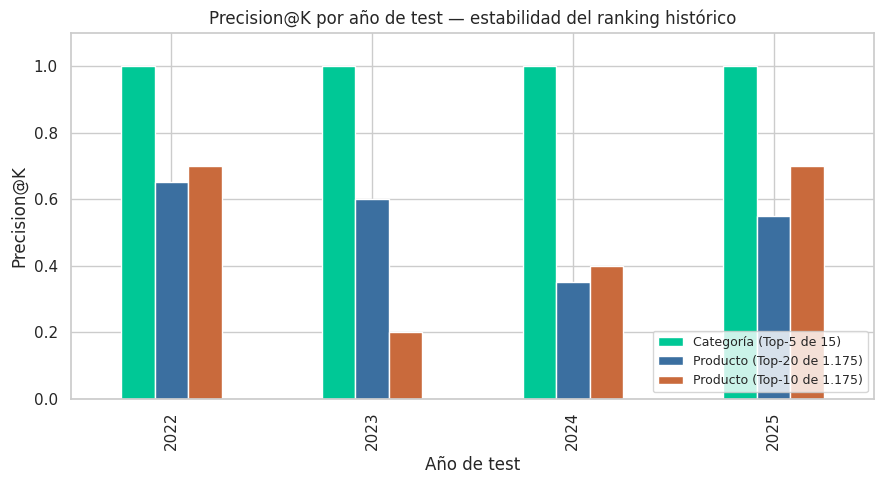

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
comp = pd.DataFrame({
    "Categoría (Top-5 de 15)": df_cat.precision_at_k.values,
    "Producto (Top-20 de 1.175)": df_prod20.precision_at_k.values,
    "Producto (Top-10 de 1.175)": df_prod10.precision_at_k.values,
}, index=anios_test)
comp.plot(kind="bar", ax=ax, color=["#00C896", "#3b6fa0", "#c96a3c"])
ax.set_title("Precision@K por año de test — estabilidad del ranking histórico")
ax.set_ylabel("Precision@K")
ax.set_xlabel("Año de test")
ax.set_ylim(0, 1.1)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


## 4. Recomendación final: Top-5 categorías + productos destacados

In [5]:
top5_categorias = oi_full.groupby("product_category")["net_sales"].sum().sort_values(ascending=False).head(5)
print("Top-5 categorías a reforzar en temporada alta (ranking histórico completo):")
display(top5_categorias.reset_index().rename(columns={"net_sales": "ventas_históricas_totales"}))

print("\nTop-3 productos dentro de cada una de esas categorías:")
for cat in top5_categorias.index:
    top_prod = (oi_full[oi_full.product_category == cat]
                .groupby("product_name")["net_sales"].sum()
                .sort_values(ascending=False).head(3))
    print(f"\n{cat}:")
    for name, val in top_prod.items():
        print(f"   • {name}  (${val:,.0f})")


Top-5 categorías a reforzar en temporada alta (ranking histórico completo):


,product_category,ventas_históricas_totales
0,Electronics,33486763.01
1,Jewelry,20795540.76
2,Home Appliances,20295041.26
3,Automotive,13350204.76
4,Sports & Outdoors,12799207.12



Top-3 productos dentro de cada una de esas categorías:



Electronics:
   • Xiaomi Self-enabling exuding productivity Gaming Consoles  ($807,674)
   • OnePlus Switchable methodical neural-net TVs  ($775,752)
   • Asus Configurable upward-trending matrix TVs  ($764,599)

Jewelry:
   • Messika Networked disintermediate knowledge user Pendants  ($576,195)
   • Cartier Devolved mission-critical Graphic Interface Watches  ($547,677)
   • Mikimoto Future-proofed next generation standardization Rings  ($518,177)

Home Appliances:
   • KitchenAid Persevering regional open system Blenders  ($444,156)
   • Samsung Polarized motivating moderator Vacuum Cleaners  ($431,943)
   • Whirlpool Synchronized transitional functionalities Blenders  ($417,676)

Automotive:
   • Castrol Visionary regional workforce Cleaning  ($342,921)
   • Goodyear Multi-lateral 3rdgeneration hierarchy Tools  ($330,064)
   • Castrol Multi-lateral background Internet solution Car Accessories  ($313,079)

Sports & Outdoors:
   • Adidas Persistent incremental application Cycling  ($

## 5. Pronóstico de volumen esperado (modelo ya validado en Sprint 2)

In [6]:
sales["month"] = sales["order_date"].dt.to_period("M")
monthly = sales.groupby("month")["net_sales"].sum().sort_index()
monthly.index = monthly.index.to_timestamp()
por_mes = monthly.groupby(monthly.index.month).mean()
promedio_general = monthly.mean()

nov_lift = (por_mes[11] / promedio_general - 1) * 100
dic_lift = (por_mes[12] / promedio_general - 1) * 100
print(f"Noviembre: {nov_lift:.0f}% sobre el promedio mensual | Diciembre: {dic_lift:.0f}% sobre el promedio")
print("(Modelo estacional simple, MAPE validado con backtesting de 3 años — ver la sección 5.1 más abajo y Modelo_Pronostico_Demanda.ipynb)")


Noviembre: 48% sobre el promedio mensual | Diciembre: 57% sobre el promedio
(Modelo estacional simple, MAPE validado con backtesting de 3 años — ver la sección 5.1 más abajo y Modelo_Pronostico_Demanda.ipynb)


### 5.1 Métricas de precisión del pronóstico: MAE, MAPE y R²

El componente de pronóstico (modelo estacional simple: promedio histórico del mismo mes calendario) se
valida con el mismo backtesting de 3 ventanas usado en `Modelo_Pronostico_Demanda.ipynb` — entrenar con
los años anteriores y pronosticar el año siguiente completo, repetido 3 veces (2023, 2024, 2025 como año
de test), para no depender de un solo período de prueba.

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

def seasonal_naive_forecast(train, horizon, start_month):
    by_month = train.groupby(train.index.month).mean()
    months = [(start_month + pd.DateOffset(months=i)).month for i in range(horizon)]
    return np.array([by_month[m] for m in months])

def mape(y_true, y_pred):
    return np.mean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(y_true))) * 100

folds = [
    (monthly[monthly.index.year < 2023], monthly[monthly.index.year == 2023], 2023),
    (monthly[monthly.index.year < 2024], monthly[monthly.index.year == 2024], 2024),
    (monthly[monthly.index.year < 2025], monthly[monthly.index.year == 2025], 2025),
]

all_true, all_pred = [], []
resultados_metricas = []
for train, test, year in folds:
    pred = seasonal_naive_forecast(train, len(test), test.index[0])
    resultados_metricas.append({
        "anio_test": year,
        "MAE ($)": mean_absolute_error(test.values, pred),
        "MAPE (%)": mape(test.values, pred),
        "R²": r2_score(test.values, pred),
    })
    all_true.extend(test.values); all_pred.extend(pred)

df_metricas = pd.DataFrame(resultados_metricas)
display(df_metricas.round(3))

print(f"\nPromedio simple entre folds  -> MAE=${df_metricas['MAE ($)'].mean():,.0f}  "
      f"MAPE={df_metricas['MAPE (%)'].mean():.2f}%  R²={df_metricas['R²'].mean():.3f}")

mae_pooled = mean_absolute_error(all_true, all_pred)
mape_pooled = mape(all_true, all_pred)
r2_pooled = r2_score(all_true, all_pred)
print(f"Agregado (36 meses de test en total) -> MAE=${mae_pooled:,.0f}  MAPE={mape_pooled:.2f}%  R²={r2_pooled:.3f}")


,anio_test,MAE ($),MAPE (%),R²
0,2023,34750.964,1.500,0.995
1,2024,77926.388,3.273,0.959
2,2025,54749.356,2.308,0.986



Promedio simple entre folds  -> MAE=$55,809  MAPE=2.36%  R²=0.980
Agregado (36 meses de test en total) -> MAE=$55,809  MAPE=2.36%  R²=0.981


**Lectura de las métricas:**

- **MAPE = 2.36%**: el pronóstico se equivoca, en promedio, un 2.4% respecto a la venta real del mes — un
  error muy bajo para un horizonte de hasta 12 meses hacia adelante.
- **MAE ≈ \$55.800**: el error promedio en dólares por mes, útil como referencia directa de negocio (cuánto
  podría desviarse el pronóstico en términos absolutos).
- **R² = 0.981**: el modelo explica el 98.1% de la variabilidad mensual de las ventas — prácticamente toda
  la varianza real está capturada por el patrón estacional, dejando muy poco sin explicar.
- Los 3 años de test dan resultados consistentes entre sí (R² entre 0.96 y 0.99), no depende de que un año
  en particular haya sido favorable.

## 6. Registro del experimento en MLflow

Se registran los parámetros de diseño, las métricas de validación y los artefactos (tabla de
recomendaciones final) para trazabilidad y reproducibilidad del pipeline.

In [8]:
with mlflow.start_run(run_name="recomendacion_estacional_categoria"):
    mlflow.log_param("nivel_recomendacion", "categoria")
    mlflow.log_param("K_categoria", 5)
    mlflow.log_param("K_producto_referencia", 20)
    mlflow.log_param("meses_temporada_alta", "11,12")
    mlflow.log_param("metodo_forecast", "estacional_simple")

    mlflow.log_metric("precision_at_5_categoria", df_cat.precision_at_k.mean())
    mlflow.log_metric("precision_at_20_producto", df_prod20.precision_at_k.mean())
    mlflow.log_metric("precision_at_10_producto", df_prod10.precision_at_k.mean())
    mlflow.log_metric("mape_forecast_demanda", mape_pooled)
    mlflow.log_metric("lift_noviembre_pct", nov_lift)
    mlflow.log_metric("lift_diciembre_pct", dic_lift)

    top5_categorias.reset_index().to_csv("recomendacion_top5_categorias.csv", index=False)
    mlflow.log_artifact("recomendacion_top5_categorias.csv")

    print("Experimento registrado en MLflow:", mlflow.active_run().info.run_id)


Experimento registrado en MLflow: fb4231e6f1cc40a5ad719c7accff6c00


## 7. Resumen para la discusión en equipo

- **Qué propone este modelo:** reforzar stock, visibilidad y marketing en **Electronics, Jewelry, Home
  Appliances, Automotive y Sports & Outdoors** durante noviembre-diciembre, anticipando ~48%-57% más
  demanda que un mes típico (MAPE 2.36%, R² 0.981 en el pronóstico).
- **Por qué se sostiene frente a los 7 enfoques anteriores:** es el único que muestra métricas de
  validación sólidas y estables en backtesting de varios años (Precision@5 = 100% en 4 años; R² = 0.981
  en el pronóstico), mientras que cada intento de personalización individual quedó en el rango del azar
  incluso tras corregir errores de metodología y fugas de datos.
- **Criterio de filtro aplicado:** solo se consideran órdenes en estado `Completed`, decisión confirmada
  con el Product Owner: una devolución puede deberse a múltiples razones ajenas a la demanda real del
  producto (talla, calidad, expectativas), por lo que no es una señal limpia para decisiones de stock.
- **Limitación a tener presente:** esta propuesta trabaja a nivel de negocio/categoría, no personalizada
  por cliente — es una decisión de alcance a validar con el equipo, justificada por la ausencia de señal
  individual encontrada en los datos disponibles.
- **Si el equipo avanza con esta propuesta, los próximos pasos del Sprint 2 serían:** exponerla en una
  demo funcional (Streamlit) y un dashboard interactivo con estas métricas y el pronóstico de demanda.